In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/home/vivek/Desktop/Netflix.csv")
print(df)
df.head(10)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [55]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [56]:
# fill null values
df['cast']=df['cast'].fillna('unknown',inplace=True)
df['country']=df['country'].fillna('unknown',inplace=True)
df['date_added']=df['date_added'].bfill()
df['rating']=df['rating'].fillna('unknown',inplace=True)


/tmp/ipykernel_2839/2609158685.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['cast']=df['cast'].fillna('unknown',inplace=True)
/tmp/ipykernel_2839/2609158685.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never work

In [57]:
# data cleaning
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

df['country'] = df['country'].str.split(',')
df = df.explode('country')
df['country'] = df['country'].str.strip()

In [58]:
df.describe()

,date_added,release_year
count,10850,10850.000000
mean,2019-05-10 12:24:57.069124,2013.999078
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-01 00:00:00,2013.000000
50%,2019-07-01 12:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.683346


1. HOW MANY MOVIES AND TV SHOWS ARE AVAILABLE IN THE DATASETS?

In [59]:
count=df['type'].value_counts()
print(count)

type
Movie      7819
TV Show    3031
Name: count, dtype: int64


/tmp/ipykernel_2839/15751040.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=count,palette='mako')


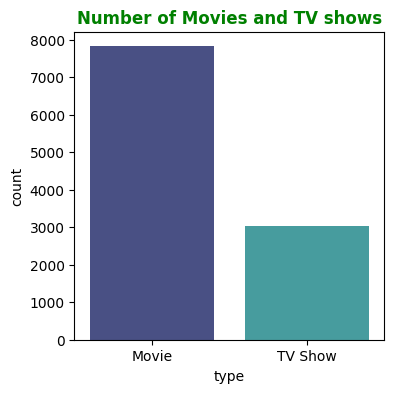

In [60]:
plt.figure(figsize=(4,4))
sns.barplot(data=count,palette='mako')
plt.title("Number of Movies and TV shows",fontweight="bold",color="green")
plt.show()

2. WHICH ARE THE TOP 10 COUNTRIES  WITH THE HIGHEST NUMBER OF NETFLIX TITLES ?

In [ ]:

top10=df.groupby('country')['title'].size().sort_values(ascending=False).head(10)
print(top10)

country
United States     3690
India             1046
unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: title, dtype: int64


/tmp/ipykernel_2839/2181399052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10,palette='deep')


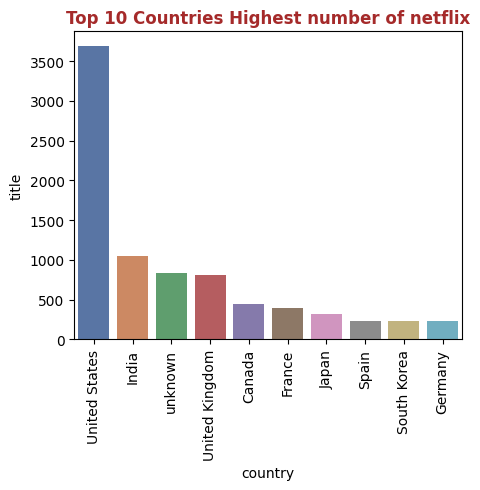

In [62]:
plt.figure(figsize=(5,4))
sns.barplot(data=top10,palette='deep')
plt.title('Top 10 Countries Highest number of netflix',fontweight="bold",color="Brown")
plt.xticks(rotation=90)
plt.show()

3. HOW HAS THE NUMBER OF TITLES RELEASED CHANGED OVER THE YAERS?

In [63]:
yearly_titles = df.groupby('release_year').size().sort_values(ascending=False).reset_index(name='Number_of_Titles')
print(yearly_titles)

    release_year  Number_of_Titles
0           2018              1392
1           2017              1276
2           2019              1208
3           2016              1155
4           2020              1055
..           ...               ...
69          1969                 2
70          1947                 1
71          1925                 1
72          1959                 1
73          1966                 1

[74 rows x 2 columns]


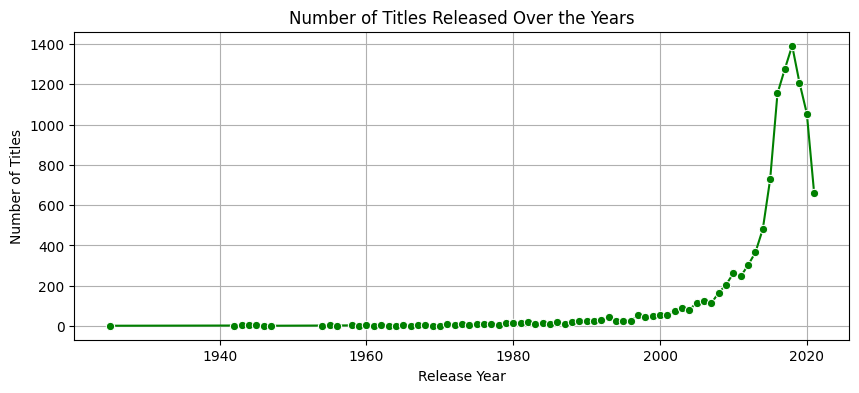

In [64]:
plt.figure(figsize=(10,4))

sns.lineplot(data=yearly_titles,
             x='release_year',
             y='Number_of_Titles',
             marker='o',
             color='green')

plt.title('Number of Titles Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)

plt.show()

4. WHICH CONTENT RATING APPEARS MOST FREQUENTLY?

In [65]:
rating=df['rating'].value_counts()
print(rating)

rating
TV-MA       3755
TV-14       2406
R           1236
TV-PG       1002
PG-13        769
TV-Y7        431
PG           429
TV-Y         382
TV-G         244
NR           110
G             62
TV-Y7-FV       8
NC-17          5
unknown        4
UR             4
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


/tmp/ipykernel_2839/323619046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating,palette='rocket_r')


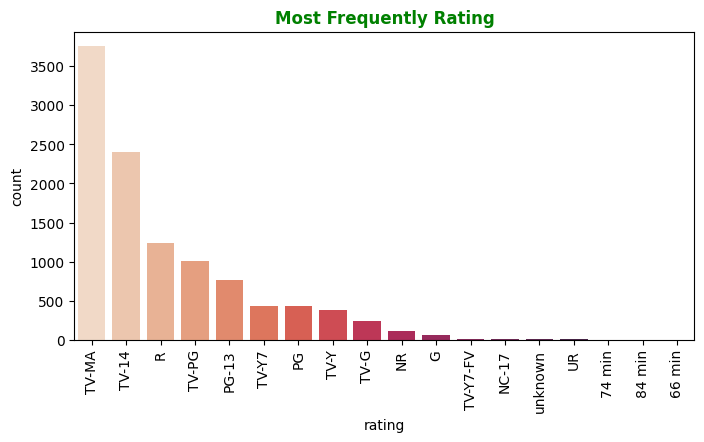

In [66]:
plt.figure(figsize=(8,4))
sns.barplot(data=rating,palette='rocket_r')
plt.title('Most Frequently Rating',fontweight='bold',color='green')
plt.xticks(rotation=90)
plt.show()

5. WHO ARE TOP 10 DIRECTORS WITH THE HIGHEST NUMBER OF TITLES ON NETFLIX 

In [67]:
df_director = df.dropna(subset=['director']).copy()

df_director['director'] = df_director['director'].str.split(',')

df_director = df_director.explode('director')

df_director['director'] = df_director['director'].str.strip()

top10_directors = df_director['director'].value_counts().head(10)

print(top10_directors)

director
Rajiv Chilaka       22
Jan Suter           21
Raúl Campos         19
Steven Spielberg    18
Martin Scorsese     18
Youssef Chahine     17
Suhas Kadav         16
Marcus Raboy        16
Martin Campbell     15
Don Michael Paul    15
Name: count, dtype: int64


/tmp/ipykernel_2839/3311342108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


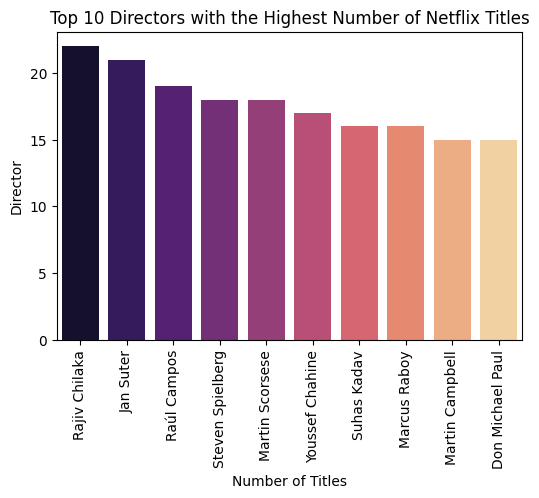

In [68]:

plt.figure(figsize=(6,4))

sns.barplot(
    data=top10_directors,
    palette='magma'
)

plt.title('Top 10 Directors with the Highest Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.xticks(rotation=90)
plt.show()

6. WHICH GENRES(LISTED_IN) ARE THE MOST POPULAR ON NETFLIX?

In [69]:
df_listed = df.dropna(subset=['listed_in']).copy()

# split value 
df_listed['listed_in'] = df_listed['listed_in'].str.split(',')

# seperate value form list 
df_listed = df_listed.explode('listed_in')

df_listed['listed_in'] = df_listed['listed_in'].str.strip()

top = df_listed['listed_in'].value_counts().head(10)

print(top)

listed_in
International Movies        3513
Dramas                      3202
Comedies                    1981
International TV Shows      1465
Action & Adventure          1182
Documentaries               1118
Independent Movies          1040
TV Dramas                    852
Children & Family Movies     845
Thrillers                    806
Name: count, dtype: int64


/tmp/ipykernel_2839/1722597435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top,palette='coolwarm')


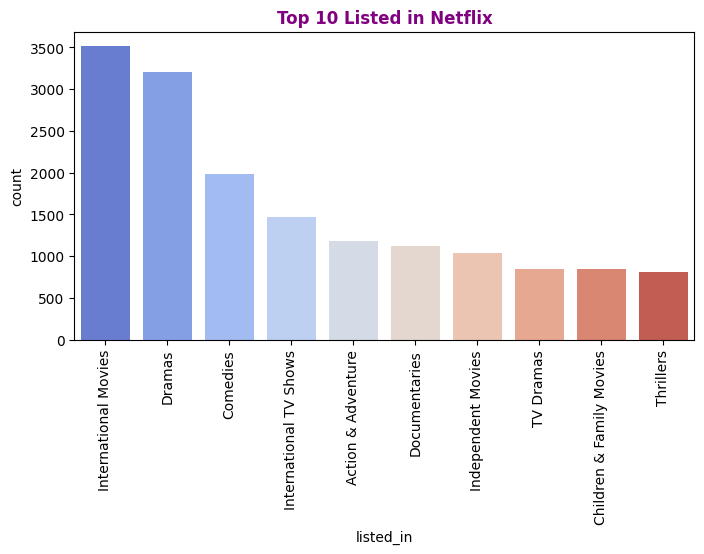

In [70]:
plt.figure(figsize=(8,4))
sns.barplot(data=top,palette='coolwarm')
plt.title('Top 10 Listed in Netflix',fontweight='bold',color='purple')
plt.xticks(rotation=90)
plt.show()

7. WHAT ARE TOP 10 YEARS IN WHICH THE MOST CONTENT WAS ADDED TO NETFLIX?

In [71]:

top10_years = df['date_added'].dt.year.value_counts().head(10)

print(top10_years)

date_added
2019    2424
2020    2340
2018    2039
2021    1831
2017    1478
2016     558
2015     106
2014      35
2011      17
2013      13
Name: count, dtype: int64


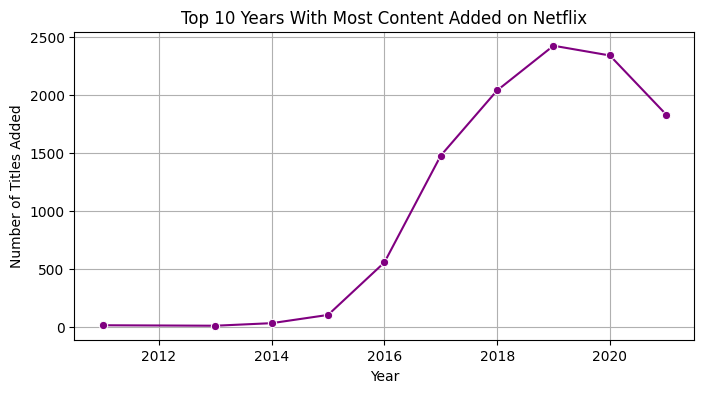

In [72]:
plt.figure(figsize=(8,4))

sns.lineplot(
    x=top10_years.index,
    y=top10_years.values,
    marker='o',
    color='purple'
)

plt.title('Top 10 Years With Most Content Added on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()


8. WHAT IS THE DISTRIBUTION OF MOVIES VS TV SHOWS BY COUNTRY?

In [73]:
df['type'].value_counts()

type
Movie      7819
TV Show    3031
Name: count, dtype: int64

In [74]:
res=(df.groupby('country')['type'].value_counts().sort_values(ascending=False).head(10)).reset_index()

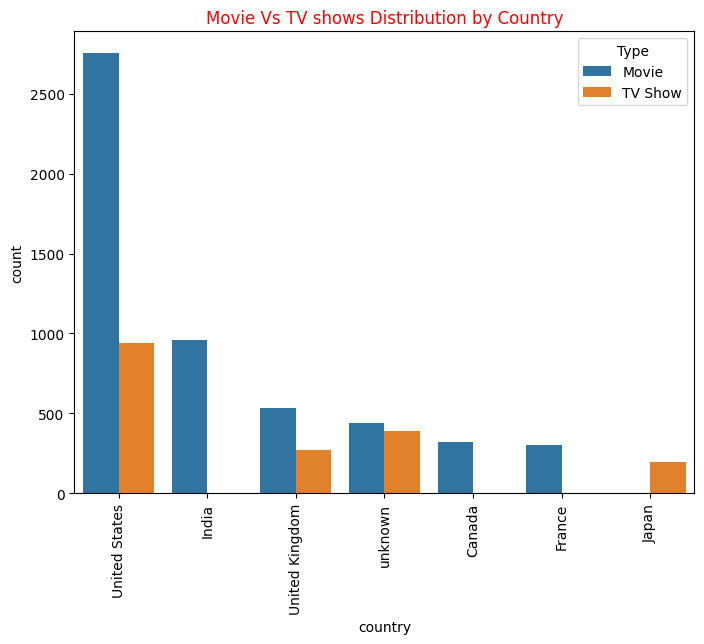

In [75]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=res,
    x='country',
    y='count',
    hue='type'
)

plt.xticks(rotation=90)
plt.title('Movie Vs TV shows Distribution by Country',color='red')
plt.legend(title='Type')
plt.show()

9. which movie have the longest duration and which tv shows have the highest number of seasons?

In [76]:
df['duration'] = df['duration'].str.extract('(\d+)')

df['duration'] = df['duration'].fillna(0).astype(int)

print(df['duration'])

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2839/583625720.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration'] = df['duration'].str.extract('(\d+)')


0        90
1         2
2         1
3         1
4         2
       ... 
8802    158
8803      2
8804     88
8805     88
8806    111
Name: duration, Length: 10850, dtype: int64


/tmp/ipykernel_2839/1231022225.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies, x='duration', y='title',palette='dark')
/tmp/ipykernel_2839/1231022225.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_shows, x='duration', y='title',palette='deep')


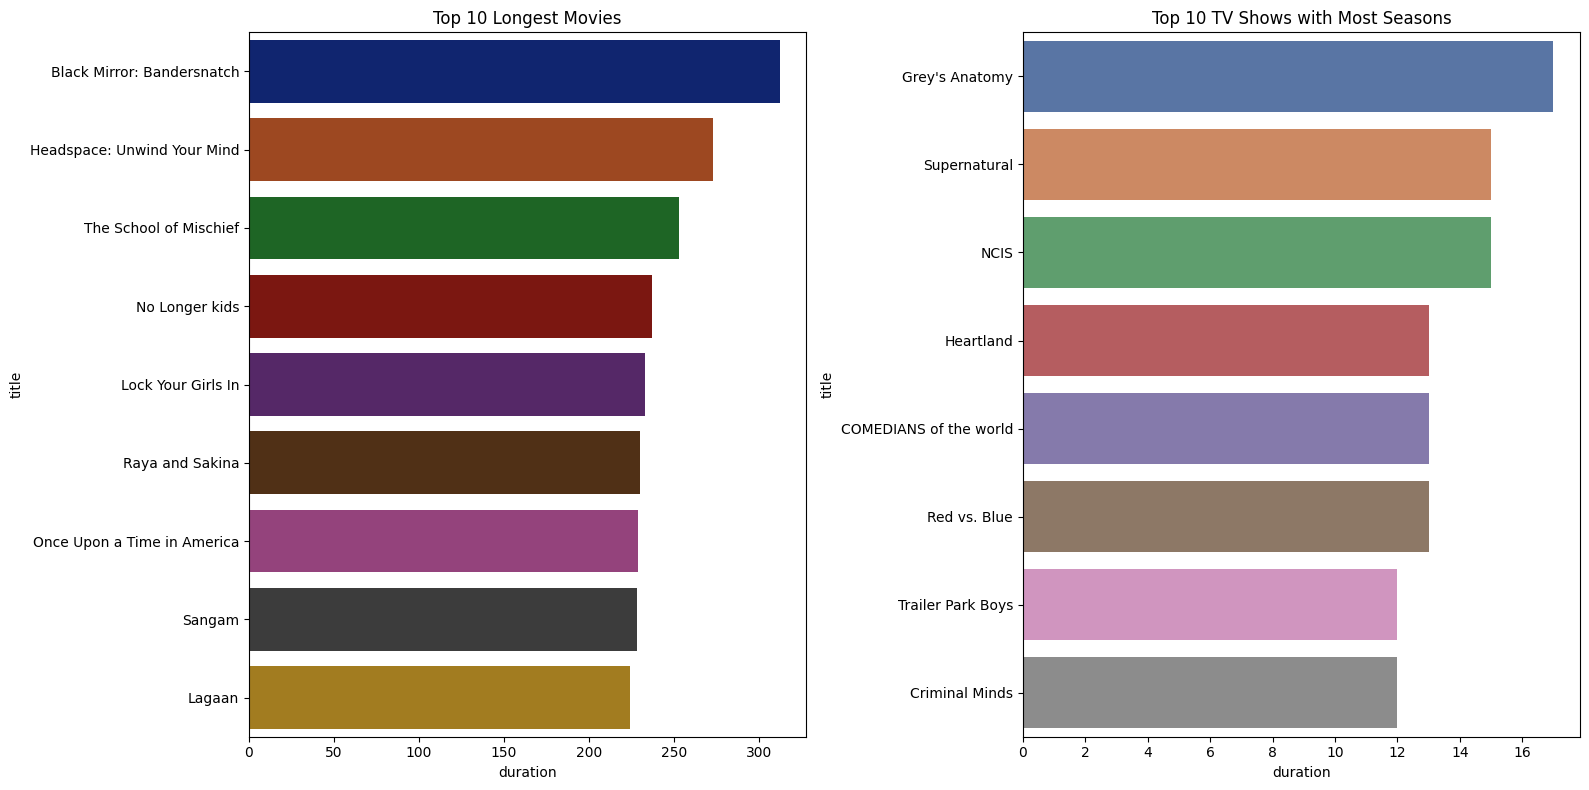

In [77]:
top_movies = df[df['type'] == 'Movie'].nlargest(10, 'duration')

# Top 10 TV Shows with Most Seasons
top_shows = df[df['type'] == 'TV Show'].nlargest(10, 'duration')

plt.figure(figsize=(16,8))

plt.subplot(1,2,1)
sns.barplot(data=top_movies, x='duration', y='title',palette='dark')
plt.title("Top 10 Longest Movies")

plt.subplot(1,2,2)
sns.barplot(data=top_shows, x='duration', y='title',palette='deep')
plt.title("Top 10 TV Shows with Most Seasons")

plt.tight_layout()
plt.show()

10. WHICH ACTORS (CAST ) APPEAR IN THE HIGHEST NUMBER OF NETFLIX TITLES?

In [91]:
df = df[df['cast']!= 'unknown']

df['cast'] = df['cast'].str.split(',')
df = df.explode('cast')
df['cast'] = df['cast'].str.strip()

top_actor=df['cast'].value_counts().head(10)
print(top_actor)

cast
Anupam Kher           46
David Attenborough    45
Vincent Tong          42
John Cleese           40
Tara Strong           39
Shah Rukh Khan        38
Andrea Libman         36
Liam Neeson           36
James Franco          35
Alfred Molina         35
Name: count, dtype: int64


/tmp/ipykernel_2839/1608429900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_actor,palette='Set1')


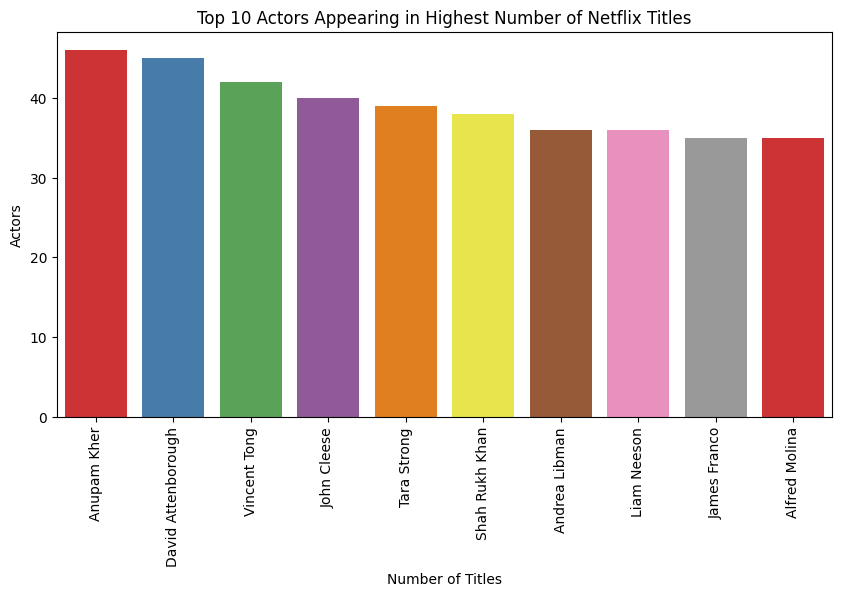

In [93]:
plt.figure(figsize=(10,5))

sns.barplot(data=top_actor,palette='Set1')

plt.title("Top 10 Actors Appearing in Highest Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Actors")
plt.xticks(rotation=90)
plt.show()